In [13]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean
from matplotlib.dates import DateFormatter


In [14]:
def select_by_latlon(ds, lat_target, lon_target):
    lat = ds['nav_lat'].values
    lon = ds['nav_lon'].values
    distance = np.sqrt((lat - lat_target)**2 + (lon - lon_target)**2)
    y_idx, x_idx = np.unravel_index(np.argmin(distance), distance.shape)
    print('x index =', x_idx)
    print('y index =', y_idx)
    return ds['tos_con'].isel(y=y_idx, x=x_idx)



In [15]:
from OceanDataStore import OceanDataCatalog

In [16]:
catalog = OceanDataCatalog(catalog_name="noc-model-stac")

In [17]:
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [18]:
catalog.available_items

['noc-npd-era5/npd-eorca1-era5v1/gn/T1y',
 'noc-npd-era5/npd-eorca1-era5v1/gn/T1m',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T1m_3d',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T5d_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T1m_3d']

In [19]:
catalog.Items[4]

<Item id=noc-npd-era5/npd-eorca025-era5v1/gn/T5d_3d>

In [20]:
ds1 = catalog.open_dataset(id=catalog.Items[4].id, start_datetime='1990-01', end_datetime='2024-12')
ds1

<xarray.Dataset> Size: 852GB
Dimensions:                (time_counter: 2555, y: 1206, x: 1440,
                            axis_nbounds: 2)
Coordinates:
  * time_counter           (time_counter) datetime64[ns] 20kB 1990-01-03T12:0...
    nav_lat                (y, x) float64 14MB dask.array<chunksize=(1206, 1440), meta=np.ndarray>
    nav_lon                (y, x) float64 14MB dask.array<chunksize=(1206, 1440), meta=np.ndarray>
    time_centered          (time_counter) datetime64[ns] 20kB dask.array<chunksize=(1,), meta=np.ndarray>
Dimensions without coordinates: y, x, axis_nbounds
Data variables: (12/50)
    berg_latent_heat_flux  (time_counter, y, x) float32 18GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    friver                 (time_counter, y, x) float32 18GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    fsitherm               (time_counter, y, x) float32 18GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    hfls                   (time_counter, y, x) float32 18GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    hfempds                (time_counter, y, x) float32 18GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    evs                    (time_counter, y, x) float32 18GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    ...                     ...
    zos                    (time_counter, y, x) float32 18GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    time_counter_bounds    (time_counter, axis_nbounds) datetime64[ns] 41kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    tnpeo                  (time_counter, y, x) float32 18GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    tossq_con              (time_counter, y, x) float32 18GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    zossq                  (time_counter, y, x) float32 18GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    tos_con                (time_counter, y, x) float32 18GB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA025_ERA5_5d_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2025-Oct-18 20:34:01 GMT
    uuid:         78bf1118-219d-4f11-9974-e1ae49742378

In [21]:
## 60N, -20W

random_point = select_by_latlon(ds1, 60, -20)

yr1990 = random_point.sel(time_counter = slice('1990-01-01', '1990-12-31'))
yr1990['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr1990['time_counter'].values])
yr1995 = random_point.sel(time_counter = slice('1995-01-01', '1995-12-31'))
yr1995['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr1995['time_counter'].values])
yr2000 = random_point.sel(time_counter = slice('2000-01-01', '2000-12-31'))
yr2000['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2000['time_counter'].values])
yr2005 = random_point.sel(time_counter = slice('2005-01-01', '2005-12-31'))
yr2005['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2005['time_counter'].values])
yr2010 = random_point.sel(time_counter = slice('2010-01-01', '2010-12-31'))
yr2010['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2010['time_counter'].values])
yr2015 = random_point.sel(time_counter = slice('2015-01-01', '2015-12-31'))
yr2015['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2015['time_counter'].values])
yr2020 = random_point.sel(time_counter = slice('2020-01-01', '2020-12-31'))
yr2020['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2020['time_counter'].values])

x index = 1064
y index = 975


In [ ]:
fig, ax = plt.subplots(figsize = (16,8))

ax.plot(yr1990['time_counter'], yr1990.values, label = '1990')
ax.plot(yr1995['time_counter'], yr1995.values, label = '1995')
print('2')
ax.plot(yr2000['time_counter'], yr2000.values, label = '2000')
ax.plot(yr2005['time_counter'], yr2005.values, label = '2005')
print('4')
ax.plot(yr2010['time_counter'], yr2010.values, label = '2010')
ax.plot(yr2015['time_counter'], yr2015.values, label = '2015')
print('6')
ax.plot(yr2020['time_counter'], yr2020.values, label = '2020')

ax.set_xlabel('Date')
ax.legend(loc = 'best')
ax.set_ylabel('Temp')
ax.set_title('Tempearture variations for 60N, -20W')
ax.xaxis.set_major_formatter(DateFormatter('%b %d'))  # e.g., "Jan 15"
plt.xticks(rotation=45, ha='right')



plt.tight_layout()

2
4


In [ ]:
## 56.00N, -82.00W (Hudson Bay)

random_point2 = select_by_latlon(ds1, 56.0, -82.0)

yr1990 = random_point2.sel(time_counter = slice('1990-01-01', '1990-12-31'))
yr1990['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr1990['time_counter'].values])
yr1995 = random_point2.sel(time_counter = slice('1995-01-01', '1995-12-31'))
yr1995['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr1995['time_counter'].values])
yr2000 = random_point2.sel(time_counter = slice('2000-01-01', '2000-12-31'))
yr2000['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2000['time_counter'].values])
yr2005 = random_point2.sel(time_counter = slice('2005-01-01', '2005-12-31'))
yr2005['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2005['time_counter'].values])
yr2010 = random_point2.sel(time_counter = slice('2010-01-01', '2010-12-31'))
yr2010['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2010['time_counter'].values])
yr2015 = random_point2.sel(time_counter = slice('2015-01-01', '2015-12-31'))
yr2015['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2015['time_counter'].values])
yr2020 = random_point2.sel(time_counter = slice('2020-01-01', '2020-12-31'))
yr2020['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2020['time_counter'].values])

fig, ax = plt.subplots(figsize = (16,8))
ax.plot(yr1990['time_counter'], yr1990.values, label = '1990')
print('1')
ax.plot(yr1995['time_counter'], yr1995.values, label = '1995')
print('2')
ax.plot(yr2000['time_counter'], yr2000.values, label = '2000')
print('3')
ax.plot(yr2005['time_counter'], yr2005.values, label = '2005')
print('4')
ax.plot(yr2010['time_counter'], yr2010.values, label = '2010')
print('5')
ax.plot(yr2015['time_counter'], yr2015.values, label = '2015')
print('6')
ax.plot(yr2020['time_counter'], yr2020.values, label = '2020')
print('7')

ax.set_xlabel('Date')
ax.legend(loc = 'best')
ax.set_ylabel('Temp')
ax.set_title('Tempearture variations for 56N, -82W')
ax.xaxis.set_major_formatter(DateFormatter('%b %d'))  # e.g., "Jan 15"
plt.xticks(rotation=45, ha='right')

In [ ]:
## 20 N, 40 W (Subtropical)

random_point3 = select_by_latlon(ds1, 20.0, -40.0)

yr1990 = random_point3.sel(time_counter = slice('1990-01-01', '1990-12-31'))
yr1990['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr1990['time_counter'].values])
yr1995 = random_point3.sel(time_counter = slice('1995-01-01', '1995-12-31'))
yr1995['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr1995['time_counter'].values])
yr2000 = random_point3.sel(time_counter = slice('2000-01-01', '2000-12-31'))
yr2000['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2000['time_counter'].values])
yr2005 = random_point3.sel(time_counter = slice('2005-01-01', '2005-12-31'))
yr2005['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2005['time_counter'].values])
yr2010 = random_point3.sel(time_counter = slice('2010-01-01', '2010-12-31'))
yr2010['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2010['time_counter'].values])
yr2015 = random_point3.sel(time_counter = slice('2015-01-01', '2015-12-31'))
yr2015['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2015['time_counter'].values])
yr2020 = random_point3.sel(time_counter = slice('2020-01-01', '2020-12-31'))
yr2020['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2020['time_counter'].values])

fig, ax = plt.subplots(figsize = (16,8))
ax.plot(yr1990['time_counter'], yr1990.values, label = '1990')
print('1')
ax.plot(yr1995['time_counter'], yr1995.values, label = '1995')
print('2')
ax.plot(yr2000['time_counter'], yr2000.values, label = '2000')
print('3')
ax.plot(yr2005['time_counter'], yr2005.values, label = '2005')
print('4')
ax.plot(yr2010['time_counter'], yr2010.values, label = '2010')
print('5')
ax.plot(yr2015['time_counter'], yr2015.values, label = '2015')
print('6')
ax.plot(yr2020['time_counter'], yr2020.values, label = '2020')
print('7')

ax.set_xlabel('Date')
ax.legend(loc = 'best')
ax.set_ylabel('Temp')
ax.set_title('Tempearture variations for 20N, -40W')
ax.xaxis.set_major_formatter(DateFormatter('%b %d'))  # e.g., "Jan 15"
plt.xticks(rotation=45, ha='right')

In [ ]:
## 43 N, 50 W (High-Amplitude patch of US North East coast)

random_point4 = select_by_latlon(ds1, 43, -50)

yr1990 = random_point4.sel(time_counter = slice('1990-01-01', '1990-12-31'))
yr1990['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr1990['time_counter'].values])
yr1995 = random_point4.sel(time_counter = slice('1995-01-01', '1995-12-31'))
yr1995['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr1995['time_counter'].values])
yr2000 = random_point4.sel(time_counter = slice('2000-01-01', '2000-12-31'))
yr2000['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2000['time_counter'].values])
yr2005 = random_point4.sel(time_counter = slice('2005-01-01', '2005-12-31'))
yr2005['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2005['time_counter'].values])
yr2010 = random_point4.sel(time_counter = slice('2010-01-01', '2010-12-31'))
yr2010['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2010['time_counter'].values])
yr2015 = random_point4.sel(time_counter = slice('2015-01-01', '2015-12-31'))
yr2015['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2015['time_counter'].values])
yr2020 = random_point4.sel(time_counter = slice('2020-01-01', '2020-12-31'))
yr2020['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2020['time_counter'].values])

fig, ax = plt.subplots(figsize = (16,8))
ax.plot(yr1990['time_counter'], yr1990.values, label = '1990')
print('1')
ax.plot(yr1995['time_counter'], yr1995.values, label = '1995')
print('2')
ax.plot(yr2000['time_counter'], yr2000.values, label = '2000')
print('3')
ax.plot(yr2005['time_counter'], yr2005.values, label = '2005')
print('4')
ax.plot(yr2010['time_counter'], yr2010.values, label = '2010')
print('5')
ax.plot(yr2015['time_counter'], yr2015.values, label = '2015')
print('6')
ax.plot(yr2020['time_counter'], yr2020.values, label = '2020')
print('7')

ax.set_xlabel('Date')
ax.legend(loc = 'best')
ax.set_ylabel('Temp')
ax.set_title('Tempearture variations for 43N, -50W')
ax.xaxis.set_major_formatter(DateFormatter('%b %d'))  # e.g., "Jan 15"
plt.xticks(rotation=45, ha='right')

x index = 988
y index = 833
1
2
3
4
5
6
7


(array([10957., 11017., 11078., 11139., 11201., 11262., 11323.]),
 [Text(10957.0, 0, 'Jan 01'),
  Text(11017.0, 0, 'Mar 01'),
  Text(11078.0, 0, 'May 01'),
  Text(11139.0, 0, 'Jul 01'),
  Text(11201.0, 0, 'Sep 01'),
  Text(11262.0, 0, 'Nov 01'),
  Text(11323.0, 0, 'Jan 01')])

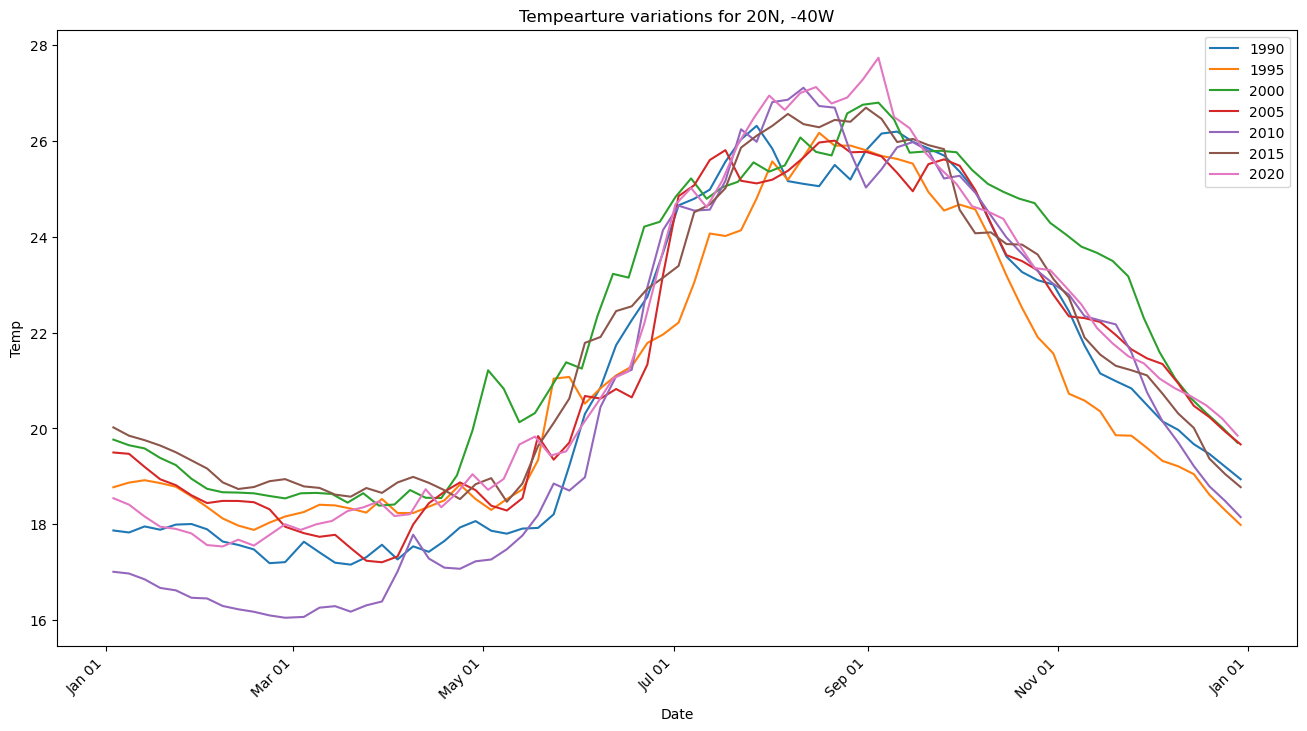

In [15]:
## 35 N, 40 W 

random_point5 = select_by_latlon(ds1, 35, -40)

yr1990 = random_point5.sel(time_counter = slice('1990-01-01', '1990-12-31'))
yr1990['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr1990['time_counter'].values])
yr1995 = random_point5.sel(time_counter = slice('1995-01-01', '1995-12-31'))
yr1995['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr1995['time_counter'].values])
yr2000 = random_point5.sel(time_counter = slice('2000-01-01', '2000-12-31'))
yr2000['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2000['time_counter'].values])
yr2005 = random_point5.sel(time_counter = slice('2005-01-01', '2005-12-31'))
yr2005['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2005['time_counter'].values])
yr2010 = random_point5.sel(time_counter = slice('2010-01-01', '2010-12-31'))
yr2010['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2010['time_counter'].values])
yr2015 = random_point5.sel(time_counter = slice('2015-01-01', '2015-12-31'))
yr2015['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2015['time_counter'].values])
yr2020 = random_point5.sel(time_counter = slice('2020-01-01', '2020-12-31'))
yr2020['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2020['time_counter'].values])

fig, ax = plt.subplots(figsize = (16,8))
ax.plot(yr1990['time_counter'], yr1990.values, label = '1990')
print('1')
ax.plot(yr1995['time_counter'], yr1995.values, label = '1995')
print('2')
ax.plot(yr2000['time_counter'], yr2000.values, label = '2000')
print('3')
ax.plot(yr2005['time_counter'], yr2005.values, label = '2005')
print('4')
ax.plot(yr2010['time_counter'], yr2010.values, label = '2010')
print('5')
ax.plot(yr2015['time_counter'], yr2015.values, label = '2015')
print('6')
ax.plot(yr2020['time_counter'], yr2020.values, label = '2020')
print('7')

ax.set_xlabel('Date')
ax.legend(loc = 'best')
ax.set_ylabel('Temp')
ax.set_title('Tempearture variations for 35N, -40W')
ax.xaxis.set_major_formatter(DateFormatter('%b %d'))  # e.g., "Jan 15"
plt.xticks(rotation=45, ha='right')

x index = 946
y index = 1006
1
2
3
4
5
6
7


(array([10957., 11017., 11078., 11139., 11201., 11262., 11323.]),
 [Text(10957.0, 0, 'Jan 01'),
  Text(11017.0, 0, 'Mar 01'),
  Text(11078.0, 0, 'May 01'),
  Text(11139.0, 0, 'Jul 01'),
  Text(11201.0, 0, 'Sep 01'),
  Text(11262.0, 0, 'Nov 01'),
  Text(11323.0, 0, 'Jan 01')])

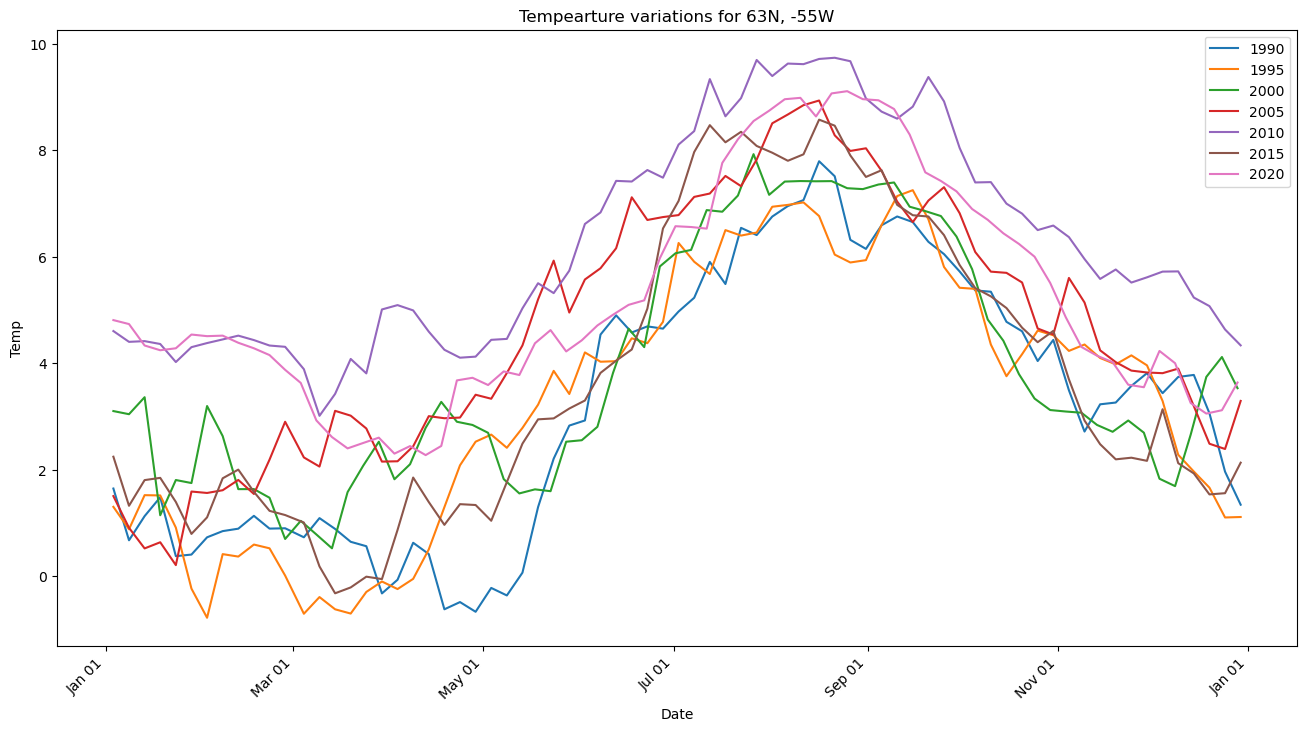

In [17]:
## 63 N, 55 W Ice Edge

random_point6 = select_by_latlon(ds1, 63, -55)

yr1990 = random_point6.sel(time_counter = slice('1990-01-01', '1990-12-31'))
yr1990['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr1990['time_counter'].values])
yr1995 = random_point6.sel(time_counter = slice('1995-01-01', '1995-12-31'))
yr1995['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr1995['time_counter'].values])
yr2000 = random_point6.sel(time_counter = slice('2000-01-01', '2000-12-31'))
yr2000['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2000['time_counter'].values])
yr2005 = random_point6.sel(time_counter = slice('2005-01-01', '2005-12-31'))
yr2005['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2005['time_counter'].values])
yr2010 = random_point6.sel(time_counter = slice('2010-01-01', '2010-12-31'))
yr2010['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2010['time_counter'].values])
yr2015 = random_point6.sel(time_counter = slice('2015-01-01', '2015-12-31'))
yr2015['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2015['time_counter'].values])
yr2020 = random_point6.sel(time_counter = slice('2020-01-01', '2020-12-31'))
yr2020['time_counter'] = ('time_counter', [pd.Timestamp(d).replace(year = 2000) for d in yr2020['time_counter'].values])

fig, ax = plt.subplots(figsize = (16,8))
ax.plot(yr1990['time_counter'], yr1990.values, label = '1990')
print('1')
ax.plot(yr1995['time_counter'], yr1995.values, label = '1995')
print('2')
ax.plot(yr2000['time_counter'], yr2000.values, label = '2000')
print('3')
ax.plot(yr2005['time_counter'], yr2005.values, label = '2005')
print('4')
ax.plot(yr2010['time_counter'], yr2010.values, label = '2010')
print('5')
ax.plot(yr2015['time_counter'], yr2015.values, label = '2015')
print('6')
ax.plot(yr2020['time_counter'], yr2020.values, label = '2020')
print('7')

ax.set_xlabel('Date')
ax.legend(loc = 'best')
ax.set_ylabel('Temp')
ax.set_title('Tempearture variations for 63N, -55W')
ax.xaxis.set_major_formatter(DateFormatter('%b %d'))  # e.g., "Jan 15"
plt.xticks(rotation=45, ha='right')